# 04 · CTR Prediction (Model B)
Trains Logistic Regression and XGBoost classifiers to predict whether an impression results in a click, and checks probability calibration — not just discrimination (AUC) — since CTR scores feed directly into auction pricing.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
from classification import train_and_evaluate
df = pd.read_csv('../data/adcore_features.csv', parse_dates=['timestamp'])
results, models = train_and_evaluate(df)
pd.DataFrame(results['comparison']).T

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,ROC_AUC,Precision,Recall,F1,LogLoss
Logistic Regression,0.9979,0.9905,0.9960,0.9932,0.0672
XGBoost Classifier,1.0000,0.9938,0.9988,0.9963,0.0047


## Calibration curve for the best model
A well-calibrated model's predicted probabilities should track the observed click rate closely — points near the diagonal are good.

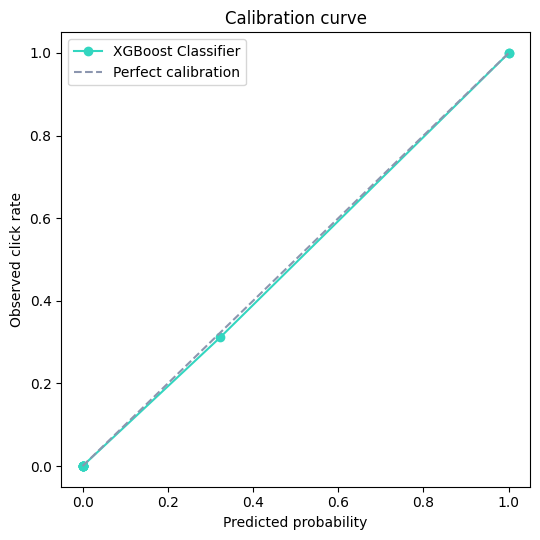

In [2]:
import matplotlib.pyplot as plt
cal = results['curves']['calibration']
fig, ax = plt.subplots(figsize=(5.5,5.5))
ax.plot(cal['predicted_probability'], cal['observed_click_rate'],
        marker='o', color='#33D6C0', label=results['best_model'])
ax.plot([0,1],[0,1], linestyle='--', color='#8C96AF', label='Perfect calibration')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed click rate')
ax.set_title('Calibration curve'); ax.legend()
plt.tight_layout(); plt.show()

## ROC curve

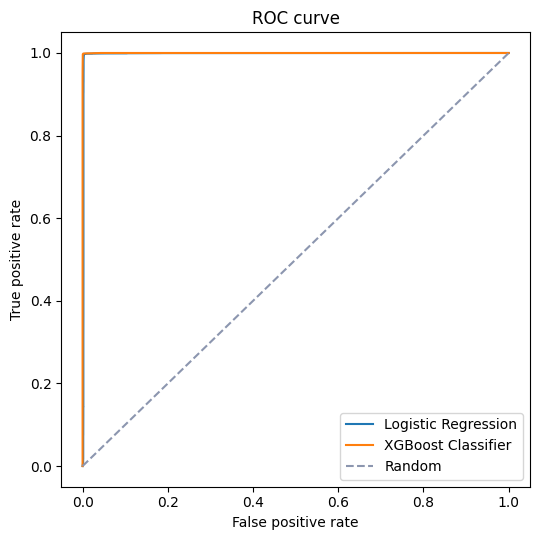

In [3]:
fig, ax = plt.subplots(figsize=(5.5,5.5))
for name, curve in results['curves']['roc'].items():
    ax.plot(curve['fpr'], curve['tpr'], label=name)
ax.plot([0,1],[0,1], linestyle='--', color='#8C96AF', label='Random')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve'); ax.legend()
plt.tight_layout(); plt.show()